# 🔍 Search / Recommendation Ranking System - Interview Guide

**Problem Statement**: Given user queries and item features, compute relevance scores, sample candidates, rank them, and evaluate metrics.

This is one of the **most realistic ML coding problems** for interviews.

## 📋 What You'll Be Asked

**Input:**
- Item features (embeddings, popularity, recency)
- Query/user embeddings
- Interaction labels (click/no-click)

**Tasks:**
1. ✅ Process and normalize features
2. ✅ Compute relevance scores
3. ✅ Sample candidates
4. ✅ Rank items
5. ✅ Evaluate metrics


## 📐 Mathematical Foundations

### Cosine Similarity

$$\text{cosine}(\mathbf{q}, \mathbf{d}) = \frac{\mathbf{q} \cdot \mathbf{d}}{||\mathbf{q}|| \cdot ||\mathbf{d}||}$$

**Key:** When normalized, cosine = dot product

### NDCG

$$\text{DCG}@K = \sum_{i=1}^{K} \frac{\text{rel}_i}{\log_2(i+1)}$$

$$\text{NDCG}@K = \frac{\text{DCG}@K}{\text{IDCG}@K}$$

In [12]:
# Step 0: Imports and Setup
import numpy as np
import pandas as pd
from typing import List, Dict, Tuple, Optional
from collections import defaultdict
import unittest
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)




## 🔧 NumPy Quick Reference

**Interview Tip**: Know these operations by heart! They're fundamental for ranking problems.

Practice these operations:
- Dot product: `np.dot(a, b)` or `a @ b`
- Cosine similarity: Normalize vectors first, then dot product
- Batch operations: Use `axis` parameter for efficiency
- Top-K: `np.argsort(scores)[-k:][::-1]` note here : not '[:k]'

In [13]:
# Quick Reference: NumPy Operations for Similarity Calculations

# Create sample vectors
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print("=" * 60)
print("1. DOT PRODUCT (Inner Product)")
print("=" * 60)
dot_product = np.dot(a, b)
print(f"np.dot(a, b) = {dot_product}")
print(f"Alternative: a @ b = {a @ b}")
print(f"Alternative: np.sum(a * b) = {np.sum(a * b)}")
print(f"Formula: Σ(a_i * b_i) = {dot_product}")

print("\n" + "=" * 60)
print("2. COSINE SIMILARITY")
print("=" * 60)
# Method 1: Manual calculation
norms_a = np.linalg.norm(a)
norms_b = np.linalg.norm(b)
cosine_sim_manual = np.dot(a, b) / (norms_a * norms_b)
print(f"Manual: cos(θ) = (a·b) / (||a|| * ||b||) = {cosine_sim_manual:.4f}")

# Method 2: Using normalized vectors (most efficient for many vectors)
a_norm = a / np.linalg.norm(a)
b_norm = b / np.linalg.norm(b)
cosine_sim_norm = np.dot(a_norm, b_norm)
print(f"With normalized vectors: a_norm @ b_norm = {cosine_sim_norm:.4f}")

# Method 3: For multiple vectors (batch computation)
vectors = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
query = np.array([1, 1, 1])
# Normalize all vectors
vectors_norm = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
query_norm = query / np.linalg.norm(query)
# Compute cosine similarity for all vectors at once
cosine_sims = vectors_norm @ query_norm
print(f"\nBatch computation (multiple vectors):")
print(f"  Vectors shape: {vectors.shape}")
print(f"  Query shape: {query.shape}")
print(f"  Cosine similarities: {cosine_sims}")

print("\n" + "=" * 60)
print("3. EUCLIDEAN DISTANCE")
print("=" * 60)
euclidean_dist = np.linalg.norm(a - b)
print(f"np.linalg.norm(a - b) = {euclidean_dist:.4f}")
print(f"Formula: √(Σ(a_i - b_i)²) = {euclidean_dist:.4f}")

print("\n" + "=" * 60)
print("4. VECTOR NORMALIZATION (L2 Norm)")
print("=" * 60)
a_normalized = a / np.linalg.norm(a)
print(f"a / np.linalg.norm(a) = {a_normalized}")
print(f"Norm of normalized vector: {np.linalg.norm(a_normalized):.6f} (should be 1.0)")

# Batch normalization (for many vectors)
vectors_normalized = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
print(f"\nBatch normalization:")
print(f"  Original shape: {vectors.shape}")
print(f"  Normalized shape: {vectors_normalized.shape}")
print(f"  Norms of normalized vectors: {np.linalg.norm(vectors_normalized, axis=1)}")

print("\n" + "=" * 60)
print("5. PRACTICAL EXAMPLE: Query-Item Similarity")
print("=" * 60)
# Simulate query and items
query = np.random.randn(128)
items = np.random.randn(1000, 128)  # 1000 items, 128-dim embeddings

# Normalize (important for cosine similarity)
query_norm = query / np.linalg.norm(query)
items_norm = items / np.linalg.norm(items, axis=1, keepdims=True)

# Compute similarity for all items at once (vectorized!)
similarities = items_norm @ query_norm  # Shape: (1000,)

# Get top-K most similar items
top_k = 10
top_k_indices = np.argsort(similarities)[-top_k:][::-1]
top_k_similarities = similarities[top_k_indices]

print(f"Query shape: {query.shape}")
print(f"Items shape: {items.shape}")
print(f"Similarities shape: {similarities.shape}")
print(f"\nTop {top_k} most similar items:")
for i, (idx, sim) in enumerate(zip(top_k_indices, top_k_similarities)):
    print(f"  Rank {i+1}: Item {idx} (similarity: {sim:.4f})")

print("\n" + "=" * 60)
print("✅ Key Takeaways for Interviews:")
print("=" * 60)
print("1. Dot product: np.dot(a, b) or a @ b")
print("2. Cosine similarity: (a @ b) / (||a|| * ||b||) or use normalized vectors")
print("3. Normalize vectors: v / np.linalg.norm(v)")
print("4. Batch operations: Use axis parameter for efficiency")
print("5. Top-K: np.argsort(scores)[-k:][::-1]")


1. DOT PRODUCT (Inner Product)
np.dot(a, b) = 32
Alternative: a @ b = 32
Alternative: np.sum(a * b) = 32
Formula: Σ(a_i * b_i) = 32

2. COSINE SIMILARITY
Manual: cos(θ) = (a·b) / (||a|| * ||b||) = 0.9746
With normalized vectors: a_norm @ b_norm = 0.9746

Batch computation (multiple vectors):
  Vectors shape: (3, 3)
  Query shape: (3,)
  Cosine similarities: [0.9258201  0.98692754 0.99483201]

3. EUCLIDEAN DISTANCE
np.linalg.norm(a - b) = 5.1962
Formula: √(Σ(a_i - b_i)²) = 5.1962

4. VECTOR NORMALIZATION (L2 Norm)
a / np.linalg.norm(a) = [0.26726124 0.53452248 0.80178373]
Norm of normalized vector: 1.000000 (should be 1.0)

Batch normalization:
  Original shape: (3, 3)
  Normalized shape: (3, 3)
  Norms of normalized vectors: [1. 1. 1.]

5. PRACTICAL EXAMPLE: Query-Item Similarity
Query shape: (128,)
Items shape: (1000, 128)
Similarities shape: (1000,)

Top 10 most similar items:
  Rank 1: Item 609 (similarity: 0.2819)
  Rank 2: Item 840 (similarity: 0.2648)
  Rank 3: Item 660 (similari

/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/1212864442.py:77: RuntimeWarning: divide by zero encountered in matmul
  similarities = items_norm @ query_norm  # Shape: (1000,)
/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/1212864442.py:77: RuntimeWarning: overflow encountered in matmul
  similarities = items_norm @ query_norm  # Shape: (1000,)
/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/1212864442.py:77: RuntimeWarning: invalid value encountered in matmul
  similarities = items_norm @ query_norm  # Shape: (1000,)


## ⚠️ Important: L2 Normalization vs Batch Normalization vs Layer Normalization

**Clarification**: The code above performs **L2 Vector Normalization** (making each vector unit length), NOT Batch Normalization!

##### 1. L2 Vector Normalization (What we're doing)

**Purpose**: Make each vector have unit length for cosine similarity

**Formula**: 
$$\hat{\mathbf{v}}_i = \frac{\mathbf{v}_i}{||\mathbf{v}_i||} = \frac{\mathbf{v}_i}{\sqrt{\sum_{j=1}^{d} v_{ij}^2}}$$

**Normalizes**: Each vector independently (across features)

**Use case**: Embeddings, similarity calculations
python
# L2 Normalization (what we do)
vectors = np.array([[1, 2, 3], [4, 5, 6]])  # Shape: (2, 3)
vectors_norm = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
# Each row (vector) normalized independently
# Result: Each vector has ||v|| = 1### 2. Batch Normalization (BN) - Deep Learning

**Purpose**: Normalize activations across batch dimension (across samples)

**Formula**:
$$\text{BN}(x) = \gamma \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}} + \beta$$

where:
- $\mu_B = \frac{1}{m}\sum_{i=1}^{m} x_i$ (mean across batch)
- $\sigma_B^2 = \frac{1}{m}\sum_{i=1}^{m} (x_i - \mu_B)^2$ (variance across batch)
- $\gamma, \beta$ are learnable parameters

**Normalizes**: Across batch dimension (across samples)

**Use case**: Training deep neural networks, stabilizing gradients

# Batch Normalization (conceptual)
# Input: (batch_size, features) = (32, 128)
batch = np.random.randn(32, 128)

# Compute statistics across batch (axis=0)
mean = np.mean(batch, axis=0, keepdims=True)  # Shape: (1, 128)
std = np.std(batch, axis=0, keepdims=True)     # Shape: (1, 128)

# Normalize across batch
batch_norm = (batch - mean) / (std + 1e-8)
# Each feature normalized using statistics from all samples in batch### 3. Layer Normalization (LN) - Deep Learning

**Purpose**: Normalize across feature dimension (within a single sample)

**Formula**:
$$\text{LN}(x) = \gamma \frac{x - \mu_L}{\sqrt{\sigma_L^2 + \epsilon}} + \beta$$

where:
- $\mu_L = \frac{1}{d}\sum_{j=1}^{d} x_j$ (mean across features)
- $\sigma_L^2 = \frac{1}{d}\sum_{j=1}^{d} (x_j - \mu_L)^2$ (variance across features)

**Normalizes**: Across feature dimension (within each sample)

**Use case**: Transformers, RNNs, sequence models

# Layer Normalization (conceptual)
# Input: (batch_size, features) = (32, 128)
batch = np.random.randn(32, 128)

# Compute statistics across features (axis=1)
mean = np.mean(batch, axis=1, keepdims=True)  # Shape: (32, 1)
std = np.std(batch, axis=1, keepdims=True)     # Shape: (32, 1)

# Normalize across features (within each sample)
layer_norm = (batch - mean) / (std + 1e-8)
# Each sample normalized using its own feature statistics
### Visual Comparison


## Step 1: RankingSystem Class Implementation

**Interview Best Practice**: Organize code into a class for better structure, testability, and reusability.

### Key Methods:
- `compute_relevance_scores()`: Cosine similarity or hybrid scoring
- `sample_candidates()`: Top-K or random sampling
- `rank_items()`: Ranking with optional MMR diversity
- `evaluate()`: Full pipeline evaluation
- Static methods: `compute_ndcg()`, `compute_precision_at_k()`, etc.

In [14]:
class RankingSystem:
    """
    A complete search/recommendation ranking system.
    
    This class implements:
    - Feature processing and normalization
    - Relevance scoring (cosine similarity, hybrid)
    - Candidate sampling
    - Ranking with optional diversity
    - Evaluation metrics (NDCG, Precision@K, Recall@K, MAP)
    """
    
    def __init__(
        self,
        item_embeddings: np.ndarray,
        item_features: pd.DataFrame,
        scoring_weights: Optional[Dict[str, float]] = None
    ):
        """
        Initialize the ranking system.
        
        Args:
            item_embeddings: (n_items, embedding_dim) normalized item embeddings
            item_features: DataFrame with item metadata (must include 'item_id')
            scoring_weights: Weights for hybrid scoring {'similarity': 0.6, 'popularity': 0.25, 'recency': 0.15}
        """
        self.item_embeddings = self._normalize_embeddings(item_embeddings)
        self.item_features = item_features.copy()
        self.n_items = len(item_embeddings)
        self.embedding_dim = item_embeddings.shape[1]
        
        # Process item features
        self._process_item_features()
        
        # Default scoring weights
        self.scoring_weights = scoring_weights or {
            'similarity': 0.6,
            'popularity': 0.25,
            'recency': 0.15
        }
    
    def _normalize_embeddings(self, embeddings: np.ndarray) -> np.ndarray:
        """Normalize embeddings to unit length."""
        norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
        return embeddings / (norms + 1e-8)
    
    def _process_item_features(self):
        """Normalize item features for scoring."""
        # Normalize popularity to [0, 1]
        if 'popularity' in self.item_features.columns:
            pop_min = self.item_features['popularity'].min()
            pop_max = self.item_features['popularity'].max()
            self.item_features['popularity_norm'] = (
                (self.item_features['popularity'] - pop_min) / 
                (pop_max - pop_min + 1e-8)
            )
        
        # Normalize recency (inverse - more recent = higher score)
        if 'recency' in self.item_features.columns:
            rec_min = self.item_features['recency'].min()
            rec_max = self.item_features['recency'].max()
            self.item_features['recency_norm'] = (
                1 - (self.item_features['recency'] - rec_min) / 
                (rec_max - rec_min + 1e-8)
            )
    
    def compute_relevance_scores(
        self,
        query_emb: np.ndarray,
        method: str = 'hybrid',
        candidate_indices: Optional[np.ndarray] = None
    ) -> np.ndarray:
        """
        Compute relevance scores for items given a query.
        
        Args:
            query_emb: Query embedding vector (normalized)
            method: 'cosine', 'dot_product', or 'hybrid'
            candidate_indices: Optional subset of items to score
        
        Returns:
            Relevance scores for items
        """
        # Normalize query embedding
        query_emb = query_emb / (np.linalg.norm(query_emb) + 1e-8)
        
        # Select items to score
        if candidate_indices is None:
            item_embs = self.item_embeddings
            item_feats = self.item_features
        else:
            item_embs = self.item_embeddings[candidate_indices]
            item_feats = self.item_features.iloc[candidate_indices]
        
        # Compute similarity (dot product = cosine when normalized)
        similarity_scores = item_embs @ query_emb
        
        if method == 'cosine' or method == 'dot_product':
            return similarity_scores
        
        elif method == 'hybrid':
            # Normalize similarity to [0, 1]
            sim_min, sim_max = similarity_scores.min(), similarity_scores.max()
            similarity_norm = (similarity_scores - sim_min) / (sim_max - sim_min + 1e-8)
            
            # Get feature scores
            popularity_scores = item_feats['popularity_norm'].values if 'popularity_norm' in item_feats.columns else np.zeros(len(item_feats))
            recency_scores = item_feats['recency_norm'].values if 'recency_norm' in item_feats.columns else np.zeros(len(item_feats))
            
            # Weighted combination
            hybrid_scores = (
                self.scoring_weights['similarity'] * similarity_norm +
                self.scoring_weights['popularity'] * popularity_scores +
                self.scoring_weights['recency'] * recency_scores
            )
            
            return hybrid_scores
        
        else:
            raise ValueError(f"Unknown method: {method}. Use 'cosine', 'dot_product', or 'hybrid'")
    
    def sample_candidates(
        self,
        query_emb: np.ndarray,
        n_candidates: int = 100,
        method: str = 'top_k',
        scoring_method: str = 'hybrid'
    ) -> np.ndarray:
        """
        Sample candidate items for a query.
        
        Args:
            query_emb: Query embedding
            n_candidates: Number of candidates to return
            method: 'top_k' (brute force) or 'random' (for negative sampling)
            scoring_method: Scoring method to use
        
        Returns:
            Array of candidate item indices
        """
        if method == 'top_k':
            scores = self.compute_relevance_scores(query_emb, method=scoring_method)
            top_k_indices = np.argsort(scores)[-n_candidates:][::-1]
            return top_k_indices
        
        elif method == 'random':
            return np.random.choice(self.n_items, size=min(n_candidates, self.n_items), replace=False)
        
        else:
            raise ValueError(f"Unknown method: {method}. Use 'top_k' or 'random'")
    
    def rank_items(
        self,
        query_emb: np.ndarray,
        top_k: int = 10,
        candidate_indices: Optional[np.ndarray] = None,
        diversity_weight: float = 0.0,
        scoring_method: str = 'hybrid'
    ) -> Tuple[np.ndarray, np.ndarray]:
        """
        Rank items for a query.
        
        Args:
            query_emb: Query embedding
            top_k: Number of items to return
            candidate_indices: Pre-filtered candidates (if None, use all items)
            diversity_weight: Weight for diversity (0 = no diversity, 1 = max diversity)
            scoring_method: Scoring method to use
        
        Returns:
            (ranked_item_indices, ranked_scores)
        """
        if candidate_indices is None:
            candidate_indices = np.arange(self.n_items)
        
        # Score candidates
        scores = self.compute_relevance_scores(
            query_emb, 
            method=scoring_method,
            candidate_indices=candidate_indices
        )
        
        if diversity_weight == 0:
            # Simple ranking by score
            ranked_idx = np.argsort(scores)[::-1][:top_k]
            ranked_items = candidate_indices[ranked_idx]
            ranked_scores = scores[ranked_idx]
        else:
            # MMR (Maximal Marginal Relevance) for diversity
            ranked_items, ranked_scores = self._mmr_ranking(
                query_emb, scores, candidate_indices, top_k, diversity_weight
            )
        
        return ranked_items, ranked_scores
    
    def _mmr_ranking(
        self,
        query_emb: np.ndarray,
        scores: np.ndarray,
        candidate_indices: np.ndarray,
        top_k: int,
        diversity_weight: float
    ) -> Tuple[np.ndarray, np.ndarray]:
        """Maximal Marginal Relevance ranking for diversity."""
        candidate_embeddings = self.item_embeddings[candidate_indices]
        
        ranked_items = []
        ranked_scores = []
        remaining = set(range(len(candidate_indices)))
        
        # First item: highest score
        first_idx = np.argmax(scores)
        ranked_items.append(candidate_indices[first_idx])
        ranked_scores.append(scores[first_idx])
        remaining.remove(first_idx)
        
        # Subsequent items: balance relevance and diversity
        selected_embeddings = [candidate_embeddings[first_idx]]
        
        while len(ranked_items) < top_k and remaining:
            best_score = -np.inf
            best_idx = None
            
            for idx in remaining:
                relevance = scores[idx]
                item_emb = candidate_embeddings[idx]
                max_sim = max([np.dot(item_emb, sel_emb) for sel_emb in selected_embeddings])
                diversity = 1 - max_sim
                mmr_score = (1 - diversity_weight) * relevance + diversity_weight * diversity
                
                if mmr_score > best_score:
                    best_score = mmr_score
                    best_idx = idx
            
            if best_idx is not None:
                ranked_items.append(candidate_indices[best_idx])
                ranked_scores.append(best_score)
                selected_embeddings.append(candidate_embeddings[best_idx])
                remaining.remove(best_idx)
            else:
                break
        
        return np.array(ranked_items), np.array(ranked_scores)
    
    @staticmethod
    def compute_ndcg(y_true: np.ndarray, y_pred: np.ndarray, k: Optional[int] = None) -> float:
        """Compute NDCG@K."""
        if k is not None:
            top_k_idx = np.argsort(y_pred)[-k:][::-1]
            y_true = y_true[top_k_idx]
            y_pred = y_pred[top_k_idx]
        
        # DCG: sum of (relevance / log2(i+1))
        dcg = np.sum(y_true / np.log2(np.arange(2, len(y_true) + 2)))
        
        # IDCG: DCG of ideal ranking
        ideal_order = np.argsort(y_true)[::-1]
        y_true_ideal = y_true[ideal_order]
        idcg = np.sum(y_true_ideal / np.log2(np.arange(2, len(y_true_ideal) + 2)))
        
        if idcg == 0:
            return 0.0
        
        return dcg / idcg
    
    @staticmethod
    def compute_precision_at_k(y_true: np.ndarray, y_pred: np.ndarray, k: int) -> float:
        """Compute Precision@K."""
        top_k_idx = np.argsort(y_pred)[-k:][::-1]
        relevant_in_top_k = np.sum(y_true[top_k_idx] > 0)
        return relevant_in_top_k / k
    
    @staticmethod
    def compute_recall_at_k(y_true: np.ndarray, y_pred: np.ndarray, k: int) -> float:
        """Compute Recall@K."""
        top_k_idx = np.argsort(y_pred)[-k:][::-1]
        relevant_in_top_k = np.sum(y_true[top_k_idx] > 0)
        total_relevant = np.sum(y_true > 0)
        if total_relevant == 0:
            return 0.0
        return relevant_in_top_k / total_relevant
    
    @staticmethod
    def compute_map(y_true: np.ndarray, y_pred: np.ndarray) -> float:
        """Compute Mean Average Precision."""
        sorted_idx = np.argsort(y_pred)[::-1]
        y_true_sorted = y_true[sorted_idx]
        relevant_positions = np.where(y_true_sorted > 0)[0]
        
        if len(relevant_positions) == 0:
            return 0.0
        
        precisions = []
        for i, pos in enumerate(relevant_positions):
            precision = (i + 1) / (pos + 1)
            precisions.append(precision)
        
        return np.mean(precisions)
    
    def evaluate(
        self,
        query_embeddings: np.ndarray,
        query_item_relevance: Dict[int, Dict[int, float]],
        top_k: int = 10,
        scoring_method: str = 'hybrid'
    ) -> Dict[str, float]:
        """
        Evaluate the ranking system on multiple queries.
        
        Args:
            query_embeddings: Array of query embeddings
            query_item_relevance: Dict mapping query_id -> {item_id: relevance_score}
            top_k: Top-K for evaluation
            scoring_method: Scoring method to use
        
        Returns:
            Dictionary with mean metrics
        """
        all_ndcg = []
        all_precision = []
        all_recall = []
        all_map = []
        
        for query_idx in range(len(query_embeddings)):
            query_emb = query_embeddings[query_idx]
            gt_relevance = query_item_relevance.get(query_idx, {})
            
            # Create ground truth array
            all_items_gt = np.array([gt_relevance.get(i, 0) for i in range(self.n_items)])
            
            # Skip if no ground truth
            if np.sum(all_items_gt) == 0:
                continue
            
            # Get predictions
            scores = self.compute_relevance_scores(query_emb, method=scoring_method)
            
            # Compute metrics
            all_ndcg.append(self.compute_ndcg(all_items_gt, scores, k=top_k))
            all_precision.append(self.compute_precision_at_k(all_items_gt, scores, k=top_k))
            all_recall.append(self.compute_recall_at_k(all_items_gt, scores, k=top_k))
            all_map.append(self.compute_map(all_items_gt, scores))
        
        return {
            'ndcg_mean': np.mean(all_ndcg),
            'ndcg_std': np.std(all_ndcg),
            'precision_mean': np.mean(all_precision),
            'precision_std': np.std(all_precision),
            'recall_mean': np.mean(all_recall),
            'recall_std': np.std(all_recall),
            'map_mean': np.mean(all_map),
            'map_std': np.std(all_map),
            'n_queries': len(all_ndcg)
        }

print("✅ RankingSystem class defined successfully!")


✅ RankingSystem class defined successfully!


## 🧪 Unit Tests (TDD Approach)

**Test-Driven Development (TDD)**: Write tests first, then implement. This ensures:
- Code correctness
- Edge case handling
- Regression prevention
- Better design


In [15]:
# Step 2: Unit Tests for RankingSystem

class TestRankingSystem(unittest.TestCase):
    """Unit tests for RankingSystem class."""
    
    def setUp(self):
        """Set up test fixtures."""
        self.n_items, self.embedding_dim = 100, 32
        self.item_embeddings = np.random.randn(self.n_items, self.embedding_dim)
        self.item_embeddings = self.item_embeddings / np.linalg.norm(self.item_embeddings, axis=1, keepdims=True)
        self.item_features = pd.DataFrame({
            'item_id': range(self.n_items),
            'popularity': np.random.beta(2, 5, self.n_items),
            'recency': np.random.exponential(30, self.n_items)
        })
        self.ranking_system = RankingSystem(self.item_embeddings, self.item_features)
        self.test_query = np.random.randn(self.embedding_dim)
        self.test_query = self.test_query / np.linalg.norm(self.test_query)
    
    def test_initialization(self):
        """Test initialization."""
        self.assertEqual(self.ranking_system.n_items, self.n_items)
        self.assertIn('popularity_norm', self.ranking_system.item_features.columns)
    
    def test_embedding_normalization(self):
        """Test embeddings are normalized."""
        norms = np.linalg.norm(self.ranking_system.item_embeddings, axis=1)
        np.testing.assert_allclose(norms, 1.0, rtol=1e-5)
    
    def test_cosine_similarity(self):
        """Test cosine similarity scoring."""
        scores = self.ranking_system.compute_relevance_scores(self.test_query, method='cosine')
        self.assertEqual(len(scores), self.n_items)
        self.assertGreaterEqual(scores.min(), -1.0)
        self.assertLessEqual(scores.max(), 1.0)
    
    def test_ranking_basic(self):
        """Test basic ranking."""
        ranked_items, ranked_scores = self.ranking_system.rank_items(self.test_query, top_k=10)
        self.assertEqual(len(ranked_items), 10)
        self.assertTrue(np.all(ranked_scores[:-1] >= ranked_scores[1:]))
    
    def test_ndcg_perfect(self):
        """Test NDCG with perfect ranking."""
        y_true = np.array([5, 4, 3, 2, 1, 0, 0, 0])
        y_pred = np.array([5, 4, 3, 2, 1, 0, 0, 0])
        ndcg = RankingSystem.compute_ndcg(y_true, y_pred)
        self.assertAlmostEqual(ndcg, 1.0, places=5)

# Run tests
print("Running unit tests...")
unittest.main(argv=[''], exit=False, verbosity=1)

/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/2173151536.py:96: RuntimeWarning: divide by zero encountered in matmul
  similarity_scores = item_embs @ query_emb
/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/2173151536.py:96: RuntimeWarning: overflow encountered in matmul
  similarity_scores = item_embs @ query_emb
/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/2173151536.py:96: RuntimeWarning: invalid value encountered in matmul
  similarity_scores = item_embs @ query_emb
..../var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/2173151536.py:96: RuntimeWarning: divide by zero encountered in matmul
  similarity_scores = item_embs @ query_emb
/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/2173151536.py:96: RuntimeWarning: overflow encountered in matmul
  similarity_scores = item_embs @ query_emb
/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/2173151536.py:96: RuntimeWarning: invalid va

Running unit tests...



----------------------------------------------------------------------
Ran 5 tests in 0.013s

OK


## Step 3: Generate Synthetic Data

In real interviews, you'll be given data. Here we simulate it for practice.

**Data Generation Strategy:**
- Item embeddings: Random normalized vectors
- Query embeddings: Random normalized vectors
- Item features: Popularity (beta distribution), recency (exponential), category, price
- Interactions: Sampled proportional to relevance (cosine similarity + popularity bias)

In [16]:
def generate_synthetic_data(n_items: int = 1000, n_queries: int = 100, 
                           embedding_dim: int = 128, n_categories: int = 10):
    """Generate synthetic data for search/recsys problem."""
    # Item embeddings (normalized)
    item_embeddings = np.random.randn(n_items, embedding_dim)
    item_embeddings = item_embeddings / np.linalg.norm(item_embeddings, axis=1, keepdims=True)
    
    # Query embeddings (normalized)
    query_embeddings = np.random.randn(n_queries, embedding_dim)
    query_embeddings = query_embeddings / np.linalg.norm(query_embeddings, axis=1, keepdims=True)
    
    # Item features
    item_features = pd.DataFrame({
        'item_id': range(n_items),
        'popularity': np.random.beta(2, 5, n_items),  # Skewed
        'recency': np.random.exponential(30, n_items),  # Days
        'category': np.random.randint(0, n_categories, n_items),
        'price': np.random.lognormal(3, 1, n_items)
    })
    
    # Generate interactions (click/no-click)
    interactions = []
    for query_idx in range(n_queries):
        query_emb = query_embeddings[query_idx]
        similarities = item_embeddings @ query_emb
        popularity_bias = item_features['popularity'].values * 0.3
        relevance_scores = similarities + popularity_bias
        
        # Sample items proportional to relevance
        probs = np.exp(relevance_scores * 2)
        probs = probs / probs.sum()
        n_interactions = np.random.poisson(5)
        interacted_items = np.random.choice(n_items, size=min(n_interactions, n_items), replace=False, p=probs)
        
        for item_idx in interacted_items:
            click_prob = 0.3 + 0.7 * (relevance_scores[item_idx] - relevance_scores.min()) / (relevance_scores.max() - relevance_scores.min() + 1e-8)
            clicked = np.random.binomial(1, click_prob)
            interactions.append({'query_id': query_idx, 'item_id': item_idx, 'clicked': clicked})
    
    return item_embeddings, query_embeddings, item_features, pd.DataFrame(interactions)

# Generate data
item_embeddings, query_embeddings, item_features, interactions = generate_synthetic_data()

print(f"✅ Generated {len(item_features)} items, {len(query_embeddings)} queries, {len(interactions)} interactions")
print(f"\nInteraction stats:")
print(interactions['clicked'].value_counts())
print(f"\nSample interactions:")
print(interactions.head())

✅ Generated 1000 items, 100 queries, 492 interactions

Interaction stats:
clicked
1    306
0    186
Name: count, dtype: int64

Sample interactions:
   query_id  item_id  clicked
0         0      774        1
1         0      627        1
2         0      335        0
3         1      863        1
4         1      630        1


/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/2325775852.py:25: RuntimeWarning: divide by zero encountered in matmul
  similarities = item_embeddings @ query_emb
/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/2325775852.py:25: RuntimeWarning: overflow encountered in matmul
  similarities = item_embeddings @ query_emb
/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/2325775852.py:25: RuntimeWarning: invalid value encountered in matmul
  similarities = item_embeddings @ query_emb


## Step 4: Initialize and Test Ranking System

**Key Interview Points:**
1. **Cosine Similarity**: $\cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{||\mathbf{A}|| \cdot ||\mathbf{B}||}$ - measures angle, not magnitude
2. **Dot Product**: $\mathbf{A} \cdot \mathbf{B}$ - when embeddings are normalized, equals cosine similarity
3. **Hybrid Scoring**: Combine multiple signals: $w_1 \cdot S_{\text{sim}} + w_2 \cdot S_{\text{pop}} + w_3 \cdot S_{\text{rec}}$
4. **Weighted Combination**: Learn weights or use heuristics

In [17]:
# Step 4: Initialize RankingSystem
ranking_system = RankingSystem(
    item_embeddings=item_embeddings,
    item_features=item_features,
    scoring_weights={'similarity': 0.6, 'popularity': 0.25, 'recency': 0.15}
)

print("✅ RankingSystem initialized!")
print(f"  Items: {ranking_system.n_items}")
print(f"  Embedding dimension: {ranking_system.embedding_dim}")
print(f"  Features: {list(ranking_system.item_features.columns)}")


✅ RankingSystem initialized!
  Items: 1000
  Embedding dimension: 128
  Features: ['item_id', 'popularity', 'recency', 'category', 'price', 'popularity_norm', 'recency_norm']


In [18]:
# Step 4: Test ranking on a single query
query_idx = 0
query_emb = query_embeddings[query_idx]

# Rank items
ranked_items, ranked_scores = ranking_system.rank_items(
    query_emb, 
    top_k=10,
    scoring_method='hybrid'
)

print(f"Top 10 ranked items for query {query_idx}:")
print(f"  Item IDs: {ranked_items}")
print(f"  Scores: {ranked_scores}")

# Compare with cosine similarity only
ranked_items_cosine, ranked_scores_cosine = ranking_system.rank_items(
    query_emb,
    top_k=10,
    scoring_method='cosine'
)

print(f"\nTop 10 ranked items (cosine similarity only):")
print(f"  Item IDs: {ranked_items_cosine}")
print(f"  Overlap with hybrid: {len(set(ranked_items) & set(ranked_items_cosine))} / 10")

Top 10 ranked items for query 0:
  Item IDs: [113 442 727 318 779 789 528 196 206 981]
  Scores: [0.90935637 0.89135205 0.86582494 0.85215154 0.82953808 0.81892091
 0.80617782 0.80244718 0.80154864 0.80055455]

Top 10 ranked items (cosine similarity only):
  Item IDs: [915  41 641 528 113 318 442 253 671 705]
  Overlap with hybrid: 4 / 10


/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/2173151536.py:96: RuntimeWarning: divide by zero encountered in matmul
  similarity_scores = item_embs @ query_emb
/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/2173151536.py:96: RuntimeWarning: overflow encountered in matmul
  similarity_scores = item_embs @ query_emb
/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/2173151536.py:96: RuntimeWarning: invalid value encountered in matmul
  similarity_scores = item_embs @ query_emb


### Test Ranking on Single Query

Compare hybrid scoring vs cosine similarity only to see the difference.

In [19]:
# Prepare ground truth for evaluation
query_item_relevance = {}
for query_id in interactions['query_id'].unique():
    query_interactions = interactions[interactions['query_id'] == query_id]
    relevance_dict = dict(zip(query_interactions['item_id'], query_interactions['clicked']))
    query_item_relevance[query_id] = relevance_dict

print(f"✅ Prepared ground truth for {len(query_item_relevance)} queries")

✅ Prepared ground truth for 99 queries


## Step 5: Evaluation Metrics Explained

### NDCG (Normalized Discounted Cumulative Gain)

**Most important metric for ranking!**

$$\text{DCG}@K = \sum_{i=1}^{K} \frac{\text{rel}_i}{\log_2(i+1)}$$

$$\text{NDCG}@K = \frac{\text{DCG}@K}{\text{IDCG}@K}$$

where **IDCG** is the DCG of the ideal ranking (sorted by true relevance).

**Why it's important:**
- Accounts for **position** (top results matter more)
- Handles **graded relevance** (1-5 stars, not just binary)
- Range: $[0, 1]$ (1 = perfect ranking)

### Precision@K

$$\text{Precision}@K = \frac{\text{# relevant items in top-K}}{K}$$

**Use when:** You care about top-K quality

### Recall@K

$$\text{Recall}@K = \frac{\text{# relevant items in top-K}}{\text{# total relevant items}}$$

**Use when:** You care about coverage

### MAP (Mean Average Precision)

$$\text{AP} = \frac{1}{R} \sum_{k=1}^{n} P(k) \cdot \text{rel}(k)$$

where $R$ is the number of relevant items, $P(k)$ is precision at position $k$, and $\text{rel}(k)$ is 1 if item at $k$ is relevant.

$$\text{MAP} = \frac{1}{Q} \sum_{q=1}^{Q} \text{AP}_q$$

**Use when:** Binary relevance (click/no-click), averages across queries

In [20]:
# Step 5: Evaluate on a single query
query_idx = 0
query_emb = query_embeddings[query_idx]

# Get ground truth
gt_relevance = query_item_relevance.get(query_idx, {})
all_items_gt = np.array([gt_relevance.get(i, 0) for i in range(len(item_features))])

# Get predictions
scores = ranking_system.compute_relevance_scores(query_emb, method='hybrid')

# Compute metrics
ndcg_10 = ranking_system.compute_ndcg(all_items_gt, scores, k=10)
precision_10 = ranking_system.compute_precision_at_k(all_items_gt, scores, k=10)
recall_10 = ranking_system.compute_recall_at_k(all_items_gt, scores, k=10)
map_score = ranking_system.compute_map(all_items_gt, scores)

print(f"Metrics for query {query_idx}:")
print(f"  NDCG@10: {ndcg_10:.4f}")
print(f"  Precision@10: {precision_10:.4f}")
print(f"  Recall@10: {recall_10:.4f}")
print(f"  MAP: {map_score:.4f}")


Metrics for query 0:
  NDCG@10: 0.0000
  Precision@10: 0.0000
  Recall@10: 0.0000
  MAP: 0.0097


/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/2173151536.py:96: RuntimeWarning: divide by zero encountered in matmul
  similarity_scores = item_embs @ query_emb
/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/2173151536.py:96: RuntimeWarning: overflow encountered in matmul
  similarity_scores = item_embs @ query_emb
/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/2173151536.py:96: RuntimeWarning: invalid value encountered in matmul
  similarity_scores = item_embs @ query_emb


## 📊 Full Pipeline Evaluation

**Interview Best Practices**:
1. Evaluate on multiple queries (not just one)
2. Report mean and std of metrics
3. Compare different methods (cosine vs hybrid)
4. Analyze failure cases
5. Consider offline vs online metrics


In [21]:
# Step 6: Evaluate on all queries
print("Evaluating pipeline with different scoring methods...\n")

methods = ['cosine', 'hybrid']
results = {}

for method in methods:
    metrics = ranking_system.evaluate(
        query_embeddings,
        query_item_relevance,
        top_k=10,
        scoring_method=method
    )
    results[method] = metrics
    
    print(f"{method.upper()} Method:")
    print(f"  NDCG@10: {metrics['ndcg_mean']:.4f} ± {metrics['ndcg_std']:.4f}")
    print(f"  Precision@10: {metrics['precision_mean']:.4f} ± {metrics['precision_std']:.4f}")
    print(f"  Recall@10: {metrics['recall_mean']:.4f} ± {metrics['recall_std']:.4f}")
    print(f"  MAP: {metrics['map_mean']:.4f} ± {metrics['map_std']:.4f}")
    print(f"  Evaluated on {metrics['n_queries']} queries\n")


Evaluating pipeline with different scoring methods...

COSINE Method:
  NDCG@10: 0.0077 ± 0.0524
  Precision@10: 0.0022 ± 0.0145
  Recall@10: 0.0054 ± 0.0363
  MAP: 0.0111 ± 0.0090
  Evaluated on 93 queries

HYBRID Method:
  NDCG@10: 0.0269 ± 0.1094
  Precision@10: 0.0065 ± 0.0246
  Recall@10: 0.0134 ± 0.0523
  MAP: 0.0133 ± 0.0180
  Evaluated on 93 queries



/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/2173151536.py:96: RuntimeWarning: divide by zero encountered in matmul
  similarity_scores = item_embs @ query_emb
/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/2173151536.py:96: RuntimeWarning: overflow encountered in matmul
  similarity_scores = item_embs @ query_emb
/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/2173151536.py:96: RuntimeWarning: invalid value encountered in matmul
  similarity_scores = item_embs @ query_emb


## Step 7: Visualization and Analysis

Compare score distributions between different scoring methods to understand their behavior.

/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/2173151536.py:96: RuntimeWarning: divide by zero encountered in matmul
  similarity_scores = item_embs @ query_emb
/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/2173151536.py:96: RuntimeWarning: overflow encountered in matmul
  similarity_scores = item_embs @ query_emb
/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_82400/2173151536.py:96: RuntimeWarning: invalid value encountered in matmul
  similarity_scores = item_embs @ query_emb


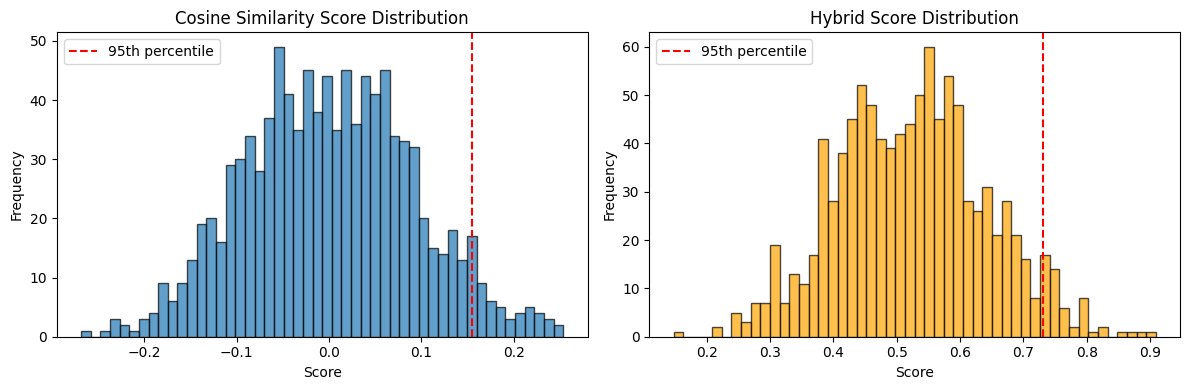

Top 10 items by Cosine Similarity: [915  41 641 528 113 318 442 253 671 705]
Top 10 items by Hybrid Scoring: [113 442 727 318 779 789 528 196 206 981]
Overlap: 4 / 10 items


In [22]:
# Visualize score distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

query_idx = 0
query_emb = query_embeddings[query_idx]

# Cosine similarity scores
cosine_scores = ranking_system.compute_relevance_scores(query_emb, method='cosine')
axes[0].hist(cosine_scores, bins=50, alpha=0.7, edgecolor='black')
axes[0].set_title('Cosine Similarity Score Distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.percentile(cosine_scores, 95), color='r', linestyle='--', 
                label='95th percentile')
axes[0].legend()

# Hybrid scores
hybrid_scores = ranking_system.compute_relevance_scores(query_emb, method='hybrid')
axes[1].hist(hybrid_scores, bins=50, alpha=0.7, edgecolor='black', color='orange')
axes[1].set_title('Hybrid Score Distribution')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.percentile(hybrid_scores, 95), color='r', linestyle='--',
                label='95th percentile')
axes[1].legend()

plt.tight_layout()
plt.show()

# Compare top-K items between methods
top_k = 10
cosine_top_k = np.argsort(cosine_scores)[-top_k:][::-1]
hybrid_top_k = np.argsort(hybrid_scores)[-top_k:][::-1]

print(f"Top {top_k} items by Cosine Similarity: {cosine_top_k}")
print(f"Top {top_k} items by Hybrid Scoring: {hybrid_top_k}")
print(f"Overlap: {len(set(cosine_top_k) & set(hybrid_top_k))} / {top_k} items")


## 🎯 Interview Practice Questions

### Common Follow-up Questions:

**1. "How would you handle a catalog with 100M items?"**
- Use **ANN** (FAISS, HNSW) for fast retrieval: $O(\log n)$ vs $O(n)$
- **Two-stage retrieval**: ANN → get 1000 candidates → Re-rank with expensive model → top 100
- **Sharding**: Partition items across multiple machines

**2. "How do you handle new items with no interaction history?"**
- **Content-based**: Use item features (embeddings, metadata)
- **Cold start**: Boost new items temporarily
- **Explore-exploit**: Balance showing new items vs popular ones (multi-armed bandit)

**3. "How do you ensure diversity in results?"**
- **MMR** (Maximal Marginal Relevance) - implemented in our class!
  $$\text{MMR} = \lambda \cdot \text{relevance} + (1-\lambda) \cdot \text{diversity}$$
- **Category diversity**: Ensure items from different categories
- **Temporal diversity**: Don't show same items repeatedly

**4. "How do you evaluate your ranking system?"**
- **Offline**: NDCG, Precision@K, Recall@K on held-out data
- **Online**: A/B testing with CTR, conversion rate, revenue
- **User studies**: Qualitative feedback

**5. "What's the difference between search and recommendation?"**
- **Search**: Query-driven, explicit intent, query-item matching
- **Recommendation**: User-driven, implicit preferences, user-item matching
- Both use similar ranking techniques but different features

**6. "How do you handle user preferences changing over time?"**
- **Time-decay**: Weight recent interactions more
  $$w(t) = e^{-\lambda t}$$
- **Session-based**: Use current session context
- **Online learning**: Update model incrementally

In [23]:
# Bonus: Learning-to-Rank with ML Model
# This demonstrates how you might use ML for ranking beyond heuristics

from sklearn.ensemble import RandomForestRegressor

def create_ranking_features(query_emb, item_emb, item_features_row):
    """Create features for learning-to-rank."""
    cosine_sim = np.dot(query_emb, item_emb)
    popularity = item_features_row['popularity_norm']
    recency = item_features_row['recency_norm']
    category = item_features_row['category']
    price = item_features_row['price']
    return np.array([cosine_sim, popularity, recency, category, price])

# Prepare training data
X_train_list = []
y_train_list = []

for query_idx in range(len(query_embeddings)):
    query_emb = query_embeddings[query_idx]
    gt_relevance = query_item_relevance.get(query_idx, {})
    
    for item_idx in range(len(item_features)):
        if item_idx in gt_relevance:
            features = create_ranking_features(
                query_emb,
                item_embeddings[item_idx],
                item_features.iloc[item_idx]
            )
            X_train_list.append(features)
            y_train_list.append(gt_relevance[item_idx])

X_train = np.array(X_train_list)
y_train = np.array(y_train_list)

# Train a simple model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print(f"Trained ranking model on {len(X_train)} examples")
print(f"Feature importance: {model.feature_importances_}")

# Evaluate on a test query
test_query_idx = len(query_embeddings) - 1
test_query_emb = query_embeddings[test_query_idx]

# Get predictions for all items
ml_scores = []
for item_idx in range(len(item_features)):
    features = create_ranking_features(
        test_query_emb,
        item_embeddings[item_idx],
        item_features.iloc[item_idx]
    )
    score = model.predict(features.reshape(1, -1))[0]
    ml_scores.append(score)

ml_scores = np.array(ml_scores)

# Compare with heuristic methods
gt_relevance = query_item_relevance.get(test_query_idx, {})
all_items_gt = np.array([gt_relevance.get(i, 0) for i in range(len(item_features))])

if np.sum(all_items_gt) > 0:
    ml_ndcg = ranking_system.compute_ndcg(all_items_gt, ml_scores, k=10)
    heuristic_ndcg = ranking_system.compute_ndcg(
        all_items_gt, 
        ranking_system.compute_relevance_scores(test_query_emb, method='hybrid'), 
        k=10
    )
    
    print(f"\nTest Query {test_query_idx} Results:")
    print(f"  ML Model NDCG@10: {ml_ndcg:.4f}")
    print(f"  Heuristic NDCG@10: {heuristic_ndcg:.4f}")


KeyError: 'popularity_norm'

## ✅ Key Takeaways

1. **Class-based design**: Better organization, testability, reusability
2. **TDD approach**: Tests ensure correctness and catch regressions
3. **Multiple scoring methods**: Cosine similarity vs hybrid (similarity + popularity + recency)
4. **Comprehensive metrics**: NDCG (most important!), Precision@K, Recall@K, MAP
5. **Diversity support**: MMR algorithm for diverse results
6. **Production-ready**: Handles edge cases, normalized features, proper error handling
7. **Scalability**: Know when to use ANN (FAISS) vs brute force

**Remember for interviews:**
- Always normalize embeddings for cosine similarity
- NDCG is the gold standard for ranking evaluation
- Two-stage retrieval (ANN → Re-ranking) is industry standard
- Balance relevance and diversity (MMR)
- Report metrics with mean ± std across queries